# 🏔️ Step 5a — Terrain Elevation, Slope, Aspect — India (SRTMGL3 90m) — Biswas et al. (2025) Topographic Predictors
## Runs alongside Step 4 (FLDAS), feeds Step 6's integrated feature stack — sibling: Step 5b (Accessibility)

**Purpose:** builds 3 of the 6 Biswas et al. (2025) predictor variables this pipeline was still
missing before this step and the sibling `Accessibility_Distance_Analysis.ipynb` notebook (same
folder, OSM-based, handled separately) — the topographic/biophysical factors: **slope** (5.6%
variable importance / **16.7% model contribution** — their *second-highest* contribution variable
after NDVI), **aspect** (1.7% / 3.8%), and **elevation** (2.4% / 2.0%). Combined, these three
account for **9.7%** of their model's total contribution. Their paper does not specify a DEM
source/resolution beyond noting these are biophysical factors.

**Data:** SRTMGL3 (90m native resolution), sourced via OpenTopography's API, already downloaded and
mosaicked to `Terrain_Outputs\India_SRTMGL3_DEM_mosaic.tif` (4 latitude bands merged with
`rasterio.merge`, EPSG:4326, shape 37200 x 35400, bounds ~68.0-97.5°E / 6.5-37.5°N).

**Grid:** slope and aspect are computed from the DEM's **native 90m resolution first** (gradient-
based features that real terrain variation would be smoothed out of if computed after downsampling
— see Step 7), then all three variables are resampled onto this project's NDVI grid (3504 x 3641 px,
EPSG:4326, ~0.01°/1km — established by Step 2), the same grid Steps 3, 4, 6 and the sibling
accessibility notebook all reproject onto. A second, coarser 0.25°x0.25° version of each variable is
also produced **purely for literature-comparison** against Biswas et al., who worked at that
resolution — see Step 10 for why these are not interchangeable.

**Method:** slope/aspect are computed with a project-native GPU-vectorized implementation of Horn's
(1981) method — the same gradient algorithm ArcGIS/QGIS/GDAL's `gdaldem`/richdem use internally —
rather than depending on `richdem` (not installed, fragile C++ build on Windows). Verified against
two synthetic test patches (Step 7) before being run on real data.

**Two judgment calls made explicit and documented in-line (see the relevant steps for full
reasoning):** (1) how the DEM's `nodata=0.0` value — which the source product uses for both open
ocean and (rarely, since this is a void-filled product) true SRTM voids — is disambiguated from
genuine near-sea-level Indian coastal/deltaic land (Step 6); (2) how aspect, a circular quantity, is
correctly averaged across the 90m-to-1km/0.25° downsampling without the 0/360-wraparound error a
naive `Resampling.average` on raw degrees would introduce (Step 9).

**Study period:** N/A for this step — SRTMGL3 is a static terrain product (imaging campaign: Feb
2000), not a time series; consistent with how Biswas et al. themselves treat elevation/slope/aspect
(static biophysical factors, not temporal variables).

## Step 0 — Install Required Libraries

Matches every other notebook's install-cell pattern in this project. If CuPy fails to
install/import, the Horn's-method computation automatically falls back to CPU (NumPy) — still
numerically correct, just slower.

In [1]:
import subprocess, sys

packages = [
    "numpy", "pandas", "matplotlib", "geopandas", "pyogrio", "rasterio", "shapely", "scipy",
    # GPU acceleration (native Windows -- no WSL required)
    "cupy-cuda12x",
    "nvidia-cuda-runtime-cu12",
    "nvidia-cuda-nvrtc-cu12",
    "nvidia-cuda-nvcc-cu12",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print("Library installation complete.")

Library installation complete.


## Step 1 — Imports & GPU Detection

Same auto-detect / auto-fallback GPU pattern used identically across every other step in this
project (CLAUDE.md's shared GPU pattern block), including the `set_pinned_memory_allocator(None)`
call after a successful GPU detect (works around the documented `cudaErrorAlreadyMapped` fragility
of CuPy's default pinned-memory transfer path on large arrays -- directly relevant here since the
DEM mosaic is a ~1.3 billion-pixel array).

In [2]:
import os, sys, time, warnings, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
from rasterio.crs import CRS
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

try:
    import cupy as cp
    _test = cp.array([1, 2, 3]) * 2   # force JIT compile now, not mid-pipeline
    GPU_AVAILABLE = True
except Exception as _e:
    import numpy as cp                 # alias so downstream cp.xxx code is unchanged
    GPU_AVAILABLE = False
    print(f"GPU not available ({_e}); falling back to CPU (NumPy)")

if GPU_AVAILABLE:
    cp.cuda.set_pinned_memory_allocator(None)
    gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    free_mem, total_mem = cp.cuda.Device(0).mem_info
    print(f"GPU acceleration ON -- {gpu_name}  ({free_mem/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total)")

def to_host(arr):
    return cp.asnumpy(arr) if GPU_AVAILABLE else arr

def free_gpu():
    if GPU_AVAILABLE:
        cp.get_default_memory_pool().free_all_blocks()

print("Imports ready.")

GPU acceleration ON -- NVIDIA RTX PRO 4500 Blackwell  (32.8 GB free / 34.2 GB total)
Imports ready.


## Step 2 — Configure Paths

In [3]:
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
STEP_DIR = os.path.join(BASE_DIR, "Terrain_Elevation_Slope_Aspect_Analysis")

# Already-downloaded and mosaicked SRTMGL3 DEM (90m native resolution)
DEM_PATH = os.path.join(STEP_DIR, "Terrain_Outputs", "India_SRTMGL3_DEM_mosaic.tif")

# Same India boundary as every other step (dissolved State boundary, EPSG:3857 raw coords)
BOUNDARY_SHP = os.path.join(BASE_DIR, "LST_analysis", "India_State_Boundary.shp")

# Step 2 (NDVI)'s own grid -- the reference grid this output is aligned onto
NDVI_GRID_REF = os.path.join(BASE_DIR, "NDVI_DATA_INDIA_", "NDVI_Fire_Susceptibility_Outputs",
                              "F1_NDVI_QA_mean.tif")

# Step 1's fire-point archive -- for the fire-coincidence check
FIRE_CSV_PATH = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)",
                              "Forest_Fire_Outputs", "all_forest_fires_2000_2022.csv")

OUTPUT_DIR = os.path.join(STEP_DIR, "Terrain_Outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded:")
print(f"   DEM mosaic    : {DEM_PATH}  (exists: {os.path.exists(DEM_PATH)})")
print(f"   Boundary      : {BOUNDARY_SHP}  (exists: {os.path.exists(BOUNDARY_SHP)})")
print(f"   NDVI grid ref : {NDVI_GRID_REF}  (exists: {os.path.exists(NDVI_GRID_REF)})")
print(f"   Fire archive  : {FIRE_CSV_PATH}  (exists: {os.path.exists(FIRE_CSV_PATH)})")
print(f"   Outputs       : {OUTPUT_DIR}")

Configuration loaded:
   DEM mosaic    : D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\India_SRTMGL3_DEM_mosaic.tif  (exists: True)
   Boundary      : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   NDVI grid ref : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs\F1_NDVI_QA_mean.tif  (exists: True)
   Fire archive  : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   Outputs       : D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs


## Step 3 — Load the NDVI Grid Reference

Pull the exact affine transform and shape from Step 2's own output raster — not hardcoded from
memory, per project convention. Also reuses its own nodata mask (`NaN` = outside India / ocean) as
the India-land mask on the 1km grid, exactly like the sibling accessibility notebook does.

In [4]:
with rasterio.open(NDVI_GRID_REF) as src:
    NDVI_TRANSFORM = src.transform
    NDVI_WIDTH, NDVI_HEIGHT = src.width, src.height
    NDVI_CRS = src.crs
    NDVI_BOUNDS = src.bounds
    ndvi_ref = src.read(1)
    NDVI_NODATA_MASK = np.isnan(ndvi_ref)  # True = outside India / ocean -- reuse for masking

valid_land = ~NDVI_NODATA_MASK

print(f"NDVI grid: {NDVI_WIDTH} x {NDVI_HEIGHT} px, CRS={NDVI_CRS}")
print(f"Transform: {NDVI_TRANSFORM}")
print(f"Bounds: {NDVI_BOUNDS}")
print(f"In-India pixels: {valid_land.sum():,} / {NDVI_WIDTH*NDVI_HEIGHT:,}")

a, b, c, d, e, f = NDVI_TRANSFORM[0], NDVI_TRANSFORM[1], NDVI_TRANSFORM[2], \
                   NDVI_TRANSFORM[3], NDVI_TRANSFORM[4], NDVI_TRANSFORM[5]
print(f"Affine coefficients a,b,c,d,e,f = {a}, {b}, {c}, {d}, {e}, {f}")

NDVI grid: 3504 x 3641 px, CRS=EPSG:4326
Transform: | 0.01, 0.00, 68.20|
| 0.00,-0.01, 37.09|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=68.19999999386121, bottom=6.7499999993924185, right=97.39999999123287, top=37.091666663327985)
In-India pixels: 4,161,009 / 12,758,064
Affine coefficients a,b,c,d,e,f = 0.008333333332583237, 0.0, 68.19999999386121, 0.0, -0.008333333332583237, 37.091666663327985


## Step 4 — India Boundary

Same boundary every other step uses: `LST_analysis\India_State_Boundary.shp` (dissolved state
boundary, has its own `.prj`) — not the root-level copies, which lack one. Raw coordinates are
EPSG:3857 (Web Mercator) meters; set that CRS explicitly if missing, then reproject to EPSG:4326
before use.

In [5]:
india_boundary = gpd.read_file(BOUNDARY_SHP)
if india_boundary.crs is None:
    india_boundary = india_boundary.set_crs(epsg=3857)
print(f"Boundary raw CRS: {india_boundary.crs}")
india_boundary_4326 = india_boundary.to_crs(epsg=4326)
india_geom = india_boundary_4326.union_all()
print(f"Boundary reprojected to EPSG:4326, bounds: {india_boundary_4326.total_bounds}")

Boundary raw CRS: EPSG:3857


Boundary reprojected to EPSG:4326, bounds: [68.12381591  6.75407754 97.40783632 37.09701157]


## Step 5 — Load the DEM, Build Per-Row Pixel Spacing, Rasterize the Land Mask

The DEM mosaic's raw (un-clipped rectangular) extent includes ocean and parts of Tibet, Nepal,
Pakistan, Bangladesh and Myanmar within its bounding box — the India land boundary is rasterized
directly onto the DEM's own native 90m grid (not the coarser NDVI grid) so masking is exact at
source resolution.

Pixel spacing is also computed here, once, since it is needed both by Step 6 (coastal-buffer
heuristic) and Step 7 (Horn's-method gradient): longitude spacing shrinks with `cos(latitude)`, and
India spans 6.75°N-37.09°N, so a single flat degrees-to-meters conversion for the whole country
would be wrong by a non-trivial amount at the northern edge — the same reasoning the sibling
accessibility notebook documents in its own Step 9.

In [6]:
print("Loading SRTMGL3 DEM mosaic (90m native resolution)...")
t0 = time.time()
with rasterio.open(DEM_PATH) as dem_src:
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs
    dem_shape = (dem_src.height, dem_src.width)
    dem_raw = dem_src.read(1)  # int16, nodata=0.0 -- see Step 6 for why that's ambiguous here
print(f"   Loaded {dem_shape[0]} x {dem_shape[1]} px, dtype={dem_raw.dtype}, CRS={dem_crs} ({time.time()-t0:.1f}s)")
print(f"   Raw un-clipped rectangular-mosaic range: {int(dem_raw.min())} to {int(dem_raw.max())} m, "
      f"mean={dem_raw.mean():.1f} m  <- includes ocean/Tibet/Nepal/Pakistan/Bangladesh/Myanmar, not India alone")

# Mean spherical Earth radius -- same simplifying assumption this project already uses elsewhere
# (e.g. PIPELINE_SUMMARY.md's cos(lat)-scaled km/degree conversions); error vs. the full WGS84
# ellipsoid is <0.3% at these latitudes, negligible next to SRTM's own ~90m horizontal / ~16m
# vertical accuracy footprint.
EARTH_RADIUS_M = 6371000.0
METERS_PER_DEG = np.pi / 180.0 * EARTH_RADIUS_M  # ~111,194.93 m/degree, both axes (spherical)
DEM_PIXEL_DEG = dem_transform.a                  # 0.00083333 deg = 3 arc-sec (SRTMGL3)
dy_m = METERS_PER_DEG * DEM_PIXEL_DEG            # constant north-south spacing (m)

row_idx = np.arange(dem_shape[0])
lat_of_row = dem_transform.f + (row_idx + 0.5) * dem_transform.e  # center latitude of each DEM row
dx_m_per_row = (METERS_PER_DEG * DEM_PIXEL_DEG * np.cos(np.radians(lat_of_row))).astype(np.float32)
print(f"   Pixel spacing: dy={dy_m:.2f} m (constant N-S) | dx={dx_m_per_row.min():.2f}-{dx_m_per_row.max():.2f} m "
      f"(E-W, shrinks {100*(1-dx_m_per_row.min()/dx_m_per_row.max()):.1f}% from India's south to north)")

print("\nRasterizing India land boundary onto the DEM's native 90m grid...")
t0 = time.time()
land_mask = rasterize(
    [(india_geom, 1)], out_shape=dem_shape, transform=dem_transform, fill=0, dtype=np.uint8
).astype(bool)
n_land = int(land_mask.sum())
print(f"   {n_land:,} / {land_mask.size:,} pixels inside India boundary ({time.time()-t0:.1f}s)")

# Keep the RAW (unmasked) elevation grid in float32 for Horn's-method gradient computation -- see
# Step 7's markdown for why the gradient step deliberately runs BEFORE land-masking.
elevation_grad = dem_raw.astype(np.float32)

Loading SRTMGL3 DEM mosaic (90m native resolution)...


   Loaded 37200 x 35400 px, dtype=int16, CRS=EPSG:4326 (7.6s)


   Raw un-clipped rectangular-mosaic range: -70 to 8735 m, mean=1212.1 m  <- includes ocean/Tibet/Nepal/Pakistan/Bangladesh/Myanmar, not India alone
   Pixel spacing: dy=92.66 m (constant N-S) | dx=73.51-92.07 m (E-W, shrinks 20.2% from India's south to north)

Rasterizing India land boundary onto the DEM's native 90m grid...


   418,470,846 / 1,316,880,000 pixels inside India boundary (18.5s)


## Step 6 — Resolving the DEM's `nodata=0` Ambiguity

The DEM mosaic declares `nodata=0.0` in its own metadata, not the usual SRTM void sentinel
`-32768`. Checked directly on this file: band 1 alone (mostly ocean) has ~87% of pixels equal to
exactly 0, consistent with OpenTopography's SRTMGL3 product using 0 for both legitimate open ocean
**and** any leftover void. This matters because genuine low-lying Indian coastal/deltaic land
(Sundarbans, Kerala backwaters, Ganges-Brahmaputra delta) sits very close to true 0m elevation and
could be wrongly discarded by a blanket "every 0-valued pixel is nodata" rule.

**Decision (documented, not a silent default):** after clipping to the actual India land polygon
(Step 5), any *remaining* exact-0m pixel is kept as genuine low elevation if it lies within 15km of
the coastline (a coarse, ~900m-resolution distance-to-non-land buffer, generous enough to cover the
Sundarbans/Kerala backwaters/Rann of Kutch), and is otherwise flagged as a likely leftover void
artifact and set to nodata (`NaN`) — since real inland India at exactly 0m, far from any coast, is
physically implausible. SRTMGL3 from OpenTopography is a void-filled product, so true voids over
land are expected to be rare-to-absent here; this step verifies that rather than assuming it.

In [7]:
print("Resolving the DEM's nodata=0 ambiguity (ocean AND true SRTM void both encoded as exactly 0)...")

zero_land_mask = land_mask & (dem_raw == 0)
n_zero_land = int(zero_land_mask.sum())
print(f"   {n_zero_land:,} pixels are exactly 0m AND inside the India land boundary "
      f"({100*n_zero_land/n_land:.3f}% of all land pixels)")

def area_km2(mask):
    counts_per_row = mask.sum(axis=1).astype(np.float64)
    return float((counts_per_row * dx_m_per_row.astype(np.float64) * dy_m).sum() / 1e6)

if n_zero_land > 0:
    # Coarse (~900m, 10x downsampled) coastline-proximity buffer -- 37200/10=3720 and 35400/10=3540
    # exactly, so no edge padding is needed for the downsample.
    DS = 10
    land_mask_ds = land_mask[::DS, ::DS]
    dist_px_ds = ndi.distance_transform_edt(land_mask_ds)  # distance (ds-px) to nearest non-land px
    dist_m_ds = dist_px_ds * (DS * dy_m)                   # coarse m/px; heuristic buffer test only
    dist_m_native = np.repeat(np.repeat(dist_m_ds, DS, axis=0), DS, axis=1)

    COASTAL_BUFFER_M = 15000.0  # 15km -- see Step 6 markdown for reasoning
    keep_lowland_mask = zero_land_mask & (dist_m_native <= COASTAL_BUFFER_M)
    suspect_void_mask = zero_land_mask & (dist_m_native > COASTAL_BUFFER_M)

    print(f"   Kept as genuine low-lying coastal/deltaic land : {int(keep_lowland_mask.sum()):,} px "
          f"(~{area_km2(keep_lowland_mask):,.0f} km2), within {COASTAL_BUFFER_M/1000:.0f} km of the coast")
    print(f"   Flagged as likely leftover void artifact       : {int(suspect_void_mask.sum()):,} px "
          f"(~{area_km2(suspect_void_mask):,.0f} km2), farther than {COASTAL_BUFFER_M/1000:.0f} km inland at exactly 0m")
    del land_mask_ds, dist_px_ds, dist_m_ds, dist_m_native
else:
    keep_lowland_mask = np.zeros_like(land_mask)
    suspect_void_mask = np.zeros_like(land_mask)
    print("   No exact-0m pixels found inside the India boundary -- nothing to resolve")

# Final REPORTING/EXPORT elevation: masked to land, flagged-void pixels set to NaN. Horn's-method
# gradients (Step 7) still use the unmasked `elevation_grad` array, so a coastal land pixel's
# slope/aspect is computed against its real ocean-ward neighbor (~0m) instead of an artificial NaN --
# only the FINAL elevation/slope/aspect values reported/exported are masked here.
elevation_report_native = np.where(land_mask, elevation_grad, np.nan).astype(np.float32)
elevation_report_native[suspect_void_mask] = np.nan
print(f"\nLand-masked native elevation range: {np.nanmin(elevation_report_native):.1f} to "
      f"{np.nanmax(elevation_report_native):.1f} m")

Resolving the DEM's nodata=0 ambiguity (ocean AND true SRTM void both encoded as exactly 0)...


   1,201,432 pixels are exactly 0m AND inside the India land boundary (0.287% of all land pixels)


   Kept as genuine low-lying coastal/deltaic land : 701,457 px (~5,678 km2), within 15 km of the coast


   Flagged as likely leftover void artifact       : 499,975 px (~3,978 km2), farther than 15 km inland at exactly 0m



Land-masked native elevation range: -70.0 to 8550.0 m


## Step 7 — Slope & Aspect at Native 90m via Horn's Method (GPU Row-Tiled)

Computed **before** any resampling to 1km/0.25° — slope/aspect are gradient-based, and computing
them after downsampling would smooth away exactly the real terrain variation that makes these
variables useful (a Q1 reviewer would flag the reversed order as a methodological error).

Standard Horn (1981) 3x3-kernel formulas (identical to what ArcGIS/GDAL's `gdaldem`/richdem compute
internally), with per-row `dx` (meters) from Step 5 so longitude-spacing shrinkage with latitude is
respected rather than using one flat conversion factor for the whole country:

```
dz/dx = ((c + 2f + i) - (a + 2d + g)) / (8 * dx)
dz/dy = ((g + 2h + i) - (a + 2b + c)) / (8 * dy)
slope (deg) = degrees(atan(hypot(dz/dx, dz/dy)))
aspect (deg, compass, 0=N/90=E/180=S/270=W) = ESRI's atan2-based remap of atan2(dz/dy, -dz/dx)
```

where `a..i` is the standard 3x3 neighborhood (`a`=NW ... `i`=SE, row 0 = north). The computation is
row-tiled (same GPU-tiling pattern the FLDAS notebook uses for its Mann-Kendall lag sweep) so the
~37200 x 35400 array never needs its full float32 gradient footprint (~5GB per array) in VRAM at
once. Flat pixels (true zero gradient) get `aspect = NaN` (undefined direction), matching ESRI's own
convention that aspect is undefined when slope = 0.

**Correctness check before running on real data:** the exact formula/sign-convention combination is
verified against two synthetic 3x3 patches with a known, unambiguous downslope direction.

In [8]:
print("Computing slope and aspect via Horn's method on the native 90m grid "
      + ("(GPU row-tiled)..." if GPU_AVAILABLE else "(CPU)..."))
t0 = time.time()

# ---- Self-test: verify the Horn's-method + ESRI aspect-remap sign convention ----
def _horn_single(a, b, c, d, f_, g, h, i, dx, dy):
    dzdx = ((c + 2*f_ + i) - (a + 2*d + g)) / (8.0 * dx)
    dzdy = ((g + 2*h + i) - (a + 2*b + c)) / (8.0 * dy)
    slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
    asp = np.degrees(np.arctan2(dzdy, -dzdx))
    if asp < 0: asp = 90.0 - asp
    elif asp > 90.0: asp = 360.0 - asp + 90.0
    else: asp = 90.0 - asp
    return slope, asp

# South-facing synthetic patch: elevation decreases south (a,b,c=100 north row; g,h,i=0 south row)
s_south, a_south = _horn_single(100, 100, 100, 50, 50, 0, 0, 0, dx=90.0, dy=90.0)
assert abs(a_south - 180.0) < 1e-6, f"South-facing self-test FAILED: expected aspect=180, got {a_south}"
# East-facing synthetic patch: elevation decreases east (a,d,g=100 west col; c,f,i=0 east col)
s_east, a_east = _horn_single(100, 50, 0, 100, 0, 100, 50, 0, dx=90.0, dy=90.0)
assert abs(a_east - 90.0) < 1e-6, f"East-facing self-test FAILED: expected aspect=90, got {a_east}"
print(f"   Sign-convention self-test passed: south-facing patch -> aspect={a_south:.1f} deg "
      f"(slope={s_south:.1f} deg), east-facing patch -> aspect={a_east:.1f} deg (slope={s_east:.1f} deg) "
      f"-- ESRI/Horn convention, 0=N, 90=E, 180=S, 270=W")

H, W = elevation_grad.shape
row_tile = 6000
pad = np.pad(elevation_grad, ((1, 1), (1, 1)), mode="edge")  # edge-replicate only at the DEM
# mosaic's own rectangular boundary -- well outside India's actual extent (Step 5 bounds)
slope_native = np.empty((H, W), dtype=np.float32)
aspect_native = np.empty((H, W), dtype=np.float32)

for r0 in range(0, H, row_tile):
    r1 = min(r0 + row_tile, H)
    window = pad[r0:r1 + 2, :]
    win_dev = cp.asarray(window) if GPU_AVAILABLE else window
    a_ = win_dev[0:-2, 0:-2]; b_ = win_dev[0:-2, 1:-1]; c_ = win_dev[0:-2, 2:]
    d_ = win_dev[1:-1, 0:-2];                            f_ = win_dev[1:-1, 2:]
    g_ = win_dev[2:, 0:-2];   h_ = win_dev[2:, 1:-1];     i_ = win_dev[2:, 2:]

    dx_tile = (cp.asarray(dx_m_per_row[r0:r1]) if GPU_AVAILABLE else dx_m_per_row[r0:r1]).reshape(-1, 1)
    dzdx = ((c_ + 2*f_ + i_) - (a_ + 2*d_ + g_)) / (8.0 * dx_tile)
    dzdy = ((g_ + 2*h_ + i_) - (a_ + 2*b_ + c_)) / (8.0 * dy_m)

    slope_tile = cp.degrees(cp.arctan(cp.hypot(dzdx, dzdy)))
    aspect_tile = cp.degrees(cp.arctan2(dzdy, -dzdx))
    aspect_tile = cp.where(aspect_tile < 0, 90.0 - aspect_tile,
                    cp.where(aspect_tile > 90.0, 360.0 - aspect_tile + 90.0, 90.0 - aspect_tile))
    # Flat convention: true zero-gradient pixels have an undefined downslope direction (ESRI's own
    # rule: aspect undefined when slope = 0). Uses a small numerical epsilon, not exact ==0, since
    # float rounding rarely lands on exact zero even on genuinely flat real terrain.
    flat = (cp.abs(dzdx) < 1e-6) & (cp.abs(dzdy) < 1e-6)
    aspect_tile = cp.where(flat, cp.float32(np.nan), aspect_tile)

    slope_native[r0:r1, :] = to_host(slope_tile)
    aspect_native[r0:r1, :] = to_host(aspect_tile)
    if GPU_AVAILABLE:
        del win_dev, a_, b_, c_, d_, f_, g_, h_, i_, dx_tile, dzdx, dzdy, slope_tile, aspect_tile, flat
        free_gpu()
    print(f"   rows {r0}:{r1} of {H} done ({time.time()-t0:.1f}s elapsed)")

del pad
gc.collect()
print(f"Slope/aspect computed on the native {H} x {W} grid in {time.time()-t0:.1f}s")

Computing slope and aspect via Horn's method on the native 90m grid (GPU row-tiled)...
   Sign-convention self-test passed: south-facing patch -> aspect=180.0 deg (slope=29.1 deg), east-facing patch -> aspect=90.0 deg (slope=29.1 deg) -- ESRI/Horn convention, 0=N, 90=E, 180=S, 270=W


   rows 0:6000 of 37200 done (3.0s elapsed)


   rows 6000:12000 of 37200 done (4.3s elapsed)


   rows 12000:18000 of 37200 done (5.7s elapsed)


   rows 18000:24000 of 37200 done (7.0s elapsed)


   rows 24000:30000 of 37200 done (8.3s elapsed)


   rows 30000:36000 of 37200 done (9.6s elapsed)


   rows 36000:37200 of 37200 done (9.9s elapsed)
Slope/aspect computed on the native 37200 x 35400 grid in 9.9s


## Step 8 — Mask Native Outputs to India, Native-Resolution Sanity Stats

Apply the land mask and the Step 6 void-flag to the computed slope/aspect (the elevation input at a
flagged void pixel is untrustworthy, so its own derived slope/aspect value is discarded too — this
does not affect neighboring pixels' values, only the flagged pixel's own outputs), then free the
large native-resolution intermediates before resampling.

In [9]:
slope_report_native = np.where(land_mask, slope_native, np.nan).astype(np.float32)
aspect_report_native = np.where(land_mask, aspect_native, np.nan).astype(np.float32)
slope_report_native[suspect_void_mask] = np.nan
aspect_report_native[suspect_void_mask] = np.nan

def circular_mean_deg(deg_array):
    valid = deg_array[~np.isnan(deg_array)]
    rad = np.radians(valid)
    return float((np.degrees(np.arctan2(np.mean(np.sin(rad)), np.mean(np.cos(rad)))) + 360) % 360)

print("=== Native 90m grid, India-masked ===")
print(f"Elevation: min={np.nanmin(elevation_report_native):.1f}  max={np.nanmax(elevation_report_native):.1f}  "
      f"mean={np.nanmean(elevation_report_native):.1f}  median={np.nanmedian(elevation_report_native):.1f} m")
print(f"Slope    : min={np.nanmin(slope_report_native):.2f}  max={np.nanmax(slope_report_native):.2f}  "
      f"mean={np.nanmean(slope_report_native):.2f}  median={np.nanmedian(slope_report_native):.2f} deg")

land_not_void = land_mask & ~suspect_void_mask
n_land_valid_aspect = int(land_not_void.sum())
n_flat_native = int(np.isnan(aspect_report_native)[land_not_void].sum())
print(f"Aspect   : circular mean={circular_mean_deg(aspect_report_native):.1f} deg  "
      f"({100*n_flat_native/n_land_valid_aspect:.2f}% of land pixels flat/undefined)")

del dem_raw, elevation_grad, slope_native, aspect_native
gc.collect()
print("\nFreed native raw/unmasked intermediates from memory (~8 GB)")

=== Native 90m grid, India-masked ===


Elevation: min=-70.0  max=8550.0  mean=738.9  median=310.0 m


Slope    : min=0.00  max=87.29  mean=5.72  median=1.21 deg


Aspect   : circular mean=150.2 deg  (0.94% of land pixels flat/undefined)

Freed native raw/unmasked intermediates from memory (~8 GB)


## Step 9 — Resample Native 90m onto the NDVI 1km Grid

Elevation and slope are continuous, non-circular fields — `Resampling.average` is the correct
choice for this ~11x11-native-pixel downsampling (matches this project's existing convention for
downsampling continuous fields, e.g. the FLDAS notebook's 300m-to-1km land-cover fractional
aggregation), not bilinear.

**Aspect is circular** — averaging raw 0-360° degree values across the wraparound is wrong (e.g.
350° and 10° would naively average to a nonsensical 180° instead of the correct 0°). Instead, the
sine and cosine components are resampled separately (each a smooth, non-wrapping continuous field,
correctly handled by `Resampling.average` with `nodata=NaN`), then recombined via `atan2` after
averaging.

**Bonus categorical version:** an 8-class + Flat aspect scheme (matching Biswas et al.'s own stated
categorical treatment of aspect) is derived from the already-correctly-resampled continuous
aspect/slope at each target resolution — not by majority-voting a native 90m categorical raster,
since a circular-mean-based continuous resample is more defensible than naive majority resampling of
discrete classes.

In [10]:
print("Reprojecting native 90m terrain layers onto the NDVI pipeline's 1km grid (Resampling.average)...")
t0 = time.time()

def reproject_average_to(src_array, dst_transform, dst_shape,
                          src_transform=dem_transform, src_crs=dem_crs, dst_crs=None):
    dst_crs = dst_crs or NDVI_CRS
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=np.ascontiguousarray(src_array.astype(np.float32)), destination=dst,
        src_transform=src_transform, src_crs=src_crs,
        dst_transform=dst_transform, dst_crs=dst_crs,
        src_nodata=np.nan, dst_nodata=np.nan,
        resampling=Resampling.average,  # 90m -> ~1km is downsampling (~11x11 native px per target px)
    )
    return dst

elevation_1km = reproject_average_to(elevation_report_native, NDVI_TRANSFORM, (NDVI_HEIGHT, NDVI_WIDTH))
slope_1km = reproject_average_to(slope_report_native, NDVI_TRANSFORM, (NDVI_HEIGHT, NDVI_WIDTH))

# Aspect: resample sin/cos separately, recombine via atan2 (see Step 9 markdown)
aspect_rad_native = np.radians(aspect_report_native)
sin_native = np.sin(aspect_rad_native).astype(np.float32)
cos_native = np.cos(aspect_rad_native).astype(np.float32)
_flat_or_masked = np.isnan(aspect_report_native)
sin_native[_flat_or_masked] = np.nan
cos_native[_flat_or_masked] = np.nan

sin_1km = reproject_average_to(sin_native, NDVI_TRANSFORM, (NDVI_HEIGHT, NDVI_WIDTH))
cos_1km = reproject_average_to(cos_native, NDVI_TRANSFORM, (NDVI_HEIGHT, NDVI_WIDTH))
aspect_1km = (np.degrees(np.arctan2(sin_1km, cos_1km)) + 360.0) % 360.0
aspect_1km[np.isnan(sin_1km) | np.isnan(cos_1km)] = np.nan

# Mask to India (reuse the NDVI grid's own nodata mask, exactly like every other step)
elevation_1km[NDVI_NODATA_MASK] = np.nan
slope_1km[NDVI_NODATA_MASK] = np.nan
aspect_1km[NDVI_NODATA_MASK] = np.nan

print(f"   Done in {time.time()-t0:.1f}s")
print(f"   Elevation (1km): {np.nanmin(elevation_1km):.1f} to {np.nanmax(elevation_1km):.1f} m, mean {np.nanmean(elevation_1km):.1f} m")
print(f"   Slope (1km)    : {np.nanmin(slope_1km):.2f} to {np.nanmax(slope_1km):.2f} deg, mean {np.nanmean(slope_1km):.2f} deg")
print(f"   Aspect (1km)   : circular mean = {circular_mean_deg(aspect_1km):.1f} deg")

# ---- Bonus: 8-class + Flat categorical aspect, derived from the resampled continuous fields ----
FLAT_CLASS_THRESHOLD_DEG = 1.0  # GIS-conventional "flat" cutoff for the categorical scheme (distinct
# from the near-exact-zero-gradient threshold used to NaN the CONTINUOUS aspect at native resolution)
ASPECT_CLASSES = {0: "Flat", 1: "N", 2: "NE", 3: "E", 4: "SE", 5: "S", 6: "SW", 7: "W", 8: "NW"}

def classify_aspect(aspect_deg, slope_deg, flat_thresh=FLAT_CLASS_THRESHOLD_DEG):
    cls = np.full(aspect_deg.shape, 255, dtype=np.uint8)  # 255 = nodata / outside India
    valid = ~np.isnan(slope_deg)
    flat = valid & (slope_deg < flat_thresh)
    cls[flat] = 0
    directional = valid & ~flat & ~np.isnan(aspect_deg)
    a_mod = aspect_deg % 360.0
    bin_idx = (np.floor((a_mod + 22.5) / 45.0) % 8).astype(np.uint8) + 1  # 1..8 -> N..NW
    cls[directional] = bin_idx[directional]
    return cls

aspect_class_1km = classify_aspect(aspect_1km, slope_1km)
print(f"   Aspect class (1km): {(aspect_class_1km==0).sum():,} Flat px, "
      f"{((aspect_class_1km>=1)&(aspect_class_1km<=8)).sum():,} directional px")

Reprojecting native 90m terrain layers onto the NDVI pipeline's 1km grid (Resampling.average)...


   Done in 48.0s
   Elevation (1km): -46.9 to 8068.9 m, mean 736.5 m
   Slope (1km)    : 0.00 to 69.63 deg, mean 5.72 deg
   Aspect (1km)   : circular mean = 161.1 deg


   Aspect class (1km): 1,751,307 Flat px, 2,409,656 directional px


## Step 10 — Two Output Resolutions, Labeled Honestly

Matching this project's existing resolution-honesty convention (see
`Integrated_Analysis\PIPELINE_SUMMARY.md`'s Resolution section, and the sibling accessibility
notebook's own Step 11): **this project's actual model consumes the native ~1km NDVI-grid version.**
A second, coarser 0.25°x0.25° version (Biswas et al.'s own working resolution, verified from their
paper: *"these datasets were in raster format with a spatial resolution of 0.25° x 0.25°"*) is
produced **purely for literature comparison** — computing summary statistics at their resolution so
they can be sanity-checked against magnitudes implied by their reported variable-importance figures.
The 0.25° raster is **not** used anywhere downstream in this pipeline (Step 6 integration reads the
native files only).

Both are resampled directly from the native 90m arrays (not by re-downsampling the already-1km
version), avoiding stacking two lossy averaging passes.

In [11]:
COMPARISON_RES_DEG = 0.25
comp_minx, comp_miny, comp_maxx, comp_maxy = NDVI_BOUNDS
COMP_WIDTH = int(np.ceil((comp_maxx - comp_minx) / COMPARISON_RES_DEG))
COMP_HEIGHT = int(np.ceil((comp_maxy - comp_miny) / COMPARISON_RES_DEG))
COMP_TRANSFORM = Affine(COMPARISON_RES_DEG, 0, comp_minx, 0, -COMPARISON_RES_DEG, comp_maxy)
print(f"0.25 deg comparison grid: {COMP_WIDTH} x {COMP_HEIGHT} px")

elevation_comp = reproject_average_to(elevation_report_native, COMP_TRANSFORM, (COMP_HEIGHT, COMP_WIDTH))
slope_comp = reproject_average_to(slope_report_native, COMP_TRANSFORM, (COMP_HEIGHT, COMP_WIDTH))
sin_comp = reproject_average_to(sin_native, COMP_TRANSFORM, (COMP_HEIGHT, COMP_WIDTH))
cos_comp = reproject_average_to(cos_native, COMP_TRANSFORM, (COMP_HEIGHT, COMP_WIDTH))
aspect_comp = (np.degrees(np.arctan2(sin_comp, cos_comp)) + 360.0) % 360.0
aspect_comp[np.isnan(sin_comp) | np.isnan(cos_comp)] = np.nan
aspect_class_comp = classify_aspect(aspect_comp, slope_comp)

print(f"   Elevation (0.25deg): {np.nanmin(elevation_comp):.1f} to {np.nanmax(elevation_comp):.1f} m, mean {np.nanmean(elevation_comp):.1f} m")
print(f"   Slope (0.25deg)    : {np.nanmin(slope_comp):.2f} to {np.nanmax(slope_comp):.2f} deg, mean {np.nanmean(slope_comp):.2f} deg")
print(f"   Aspect (0.25deg)   : circular mean = {circular_mean_deg(aspect_comp):.1f} deg")

del sin_native, cos_native, sin_1km, cos_1km, sin_comp, cos_comp
gc.collect()

0.25 deg comparison grid: 117 x 122 px


   Elevation (0.25deg): -0.2 to 6163.2 m, mean 771.2 m
   Slope (0.25deg)    : 0.00 to 38.36 deg, mean 5.95 deg
   Aspect (0.25deg)   : circular mean = 168.8 deg


0

## Step 11 — Sanity-Check Output Ranges

India's actual land elevation should range from close to sea level (with a small amount of genuine
below-sea-level coastal terrain, e.g. Kuttanad in Kerala at roughly -2m) up to a ballpark near
Kangchenjunga's ~8586m (India's highest point, on the India/Nepal/Sikkim border) — not necessarily
hitting that exact peak given SRTM void/steep-terrain issues are common at extreme altitude even in
a void-filled product. Slope is 0-90° theoretically, realistically well under that for India's
actual terrain. Aspect is 0-360°.

In [12]:
def print_stats(arr, name, unit):
    valid = arr[~np.isnan(arr)]
    pct = np.percentile(valid, [5, 25, 50, 75, 95])
    print(f"{name}:")
    print(f"   min={valid.min():.2f}{unit}  max={valid.max():.2f}{unit}  mean={valid.mean():.2f}{unit}  std={valid.std():.2f}{unit}")
    print(f"   p5={pct[0]:.2f}  p25={pct[1]:.2f}  median={pct[2]:.2f}  p75={pct[3]:.2f}  p95={pct[4]:.2f}{unit}")

print("=== NATIVE (~1km NDVI grid) ===")
print_stats(elevation_1km, "Elevation", "m")
print_stats(slope_1km, "Slope", " deg")
print(f"Aspect: circular mean={circular_mean_deg(aspect_1km):.1f} deg, "
      f"{100*np.mean(aspect_class_1km[valid_land]==0):.2f}% of land pixels classified Flat")
print()
print("=== COMPARISON-ONLY (0.25 deg, Biswas et al. working resolution) ===")
print_stats(elevation_comp, "Elevation", "m")
print_stats(slope_comp, "Slope", " deg")
_comp_valid = ~np.isnan(elevation_comp)
print(f"Aspect: circular mean={circular_mean_deg(aspect_comp):.1f} deg, "
      f"{100*np.mean(aspect_class_comp[_comp_valid]==0):.2f}% of land pixels classified Flat")

print("\nPhysical plausibility check:")
print(f"   Elevation max {np.nanmax(elevation_1km):.0f} m vs. Kangchenjunga ~8586 m "
      f"({'plausible' if 0 < np.nanmax(elevation_1km) <= 8700 else 'CHECK -- outside expected range'})")
print(f"   Elevation min {np.nanmin(elevation_1km):.1f} m vs. near-sea-level / Kuttanad ~-2 m "
      f"({'plausible' if np.nanmin(elevation_1km) >= -15 else 'CHECK -- outside expected range'})")
print(f"   Slope max {np.nanmax(slope_1km):.1f} deg ({'plausible, well under 90 deg' if np.nanmax(slope_1km) < 80 else 'CHECK'})")

=== NATIVE (~1km NDVI grid) ===
Elevation:
   min=-46.87m  max=8068.90m  mean=736.53m  std=1244.60m
   p5=25.85  p25=146.50  median=311.59  p75=583.72  p95=4400.73m
Slope:
   min=0.00 deg  max=69.63 deg  mean=5.72 deg  std=9.16 deg
   p5=0.46  p25=0.71  median=1.24  p75=5.40  p95=28.65 deg


Aspect: circular mean=161.1 deg, 42.09% of land pixels classified Flat

=== COMPARISON-ONLY (0.25 deg, Biswas et al. working resolution) ===
Elevation:
   min=-0.22m  max=6163.24m  mean=771.19m  std=1306.39m
   p5=13.56  p25=130.84  median=304.91  p75=580.77  p95=4617.80m
Slope:
   min=0.00 deg  max=38.36 deg  mean=5.95 deg  std=8.60 deg
   p5=0.55  p25=0.86  median=1.87  p75=5.85  p95=27.79 deg
Aspect: circular mean=168.8 deg, 30.97% of land pixels classified Flat

Physical plausibility check:
   Elevation max 8069 m vs. Kangchenjunga ~8586 m (plausible)
   Elevation min -46.9 m vs. near-sea-level / Kuttanad ~-2 m (CHECK -- outside expected range)
   Slope max 69.6 deg (plausible, well under 90 deg)


## Step 12 — Fire Coincidence Check

Are Step 1's real forest-fire points systematically at higher/lower slope, particular elevation
bands, or particular aspect orientations compared to the country-wide average? Uses this project's
standard fire-point rasterization pattern — affine transform coefficients directly, not a
nearest-neighbor spatial join (`col = floor((lon-c)/a)`, `row = floor((lat-f)/e)`, i.e. the pixel that contains the point; `c, f` are the top-left pixel EDGE). *Audit 2026-09-25:* the earlier `round(...)` rule displaced 74.9% of points into a neighbouring pixel.

Raw counts would be misleading here (e.g. "more fires happen at low elevation" partly just because
most of India's land area *is* low elevation) — instead this compares each bin's **share of fire
points** against its **share of land area**, giving an enrichment ratio (>1 = over-represented among
fires relative to its area, <1 = under-represented). Slope is Biswas et al.'s second-most-important
variable after NDVI, so this is the most scientifically consequential comparison of the three.

In [13]:
df_fire = pd.read_csv(FIRE_CSV_PATH, usecols=["latitude", "longitude"])
print(f"Loaded {len(df_fire):,} fire points")

fire_row = np.floor((df_fire["latitude"].values - f) / e).astype(np.int64)  # containing pixel (audit 2026-09-25)
fire_col = np.floor((df_fire["longitude"].values - c) / a).astype(np.int64)
in_bounds = (fire_row >= 0) & (fire_row < NDVI_HEIGHT) & (fire_col >= 0) & (fire_col < NDVI_WIDTH)
print(f"In NDVI grid bounds: {in_bounds.sum():,}  (excluded {int((~in_bounds).sum()):,})")
fire_row, fire_col = fire_row[in_bounds], fire_col[in_bounds]

slope_at_fire = slope_1km[fire_row, fire_col]
elev_at_fire = elevation_1km[fire_row, fire_col]
aspect_at_fire = aspect_1km[fire_row, fire_col]
aclass_at_fire = aspect_class_1km[fire_row, fire_col]

def enrichment_table(values_land, values_fire, bins, labels):
    land_valid = values_land[valid_land & ~np.isnan(values_land)]
    fire_valid = values_fire[~np.isnan(values_fire)]
    land_hist, _ = np.histogram(land_valid, bins=bins)
    fire_hist, _ = np.histogram(fire_valid, bins=bins)
    land_frac = land_hist / land_hist.sum()
    fire_frac = fire_hist / fire_hist.sum()
    ratio = np.where(land_frac > 0, fire_frac / land_frac, np.nan)
    return pd.DataFrame({"bin": labels, "land_area_pct": 100*land_frac, "fire_pct": 100*fire_frac,
                          "enrichment_ratio": ratio})

SLOPE_BINS = [0, 5, 10, 15, 20, 25, 30, 90]
SLOPE_LABELS = ["0-5", "5-10", "10-15", "15-20", "20-25", "25-30", "30+"]
df_slope_enrich = enrichment_table(slope_1km, slope_at_fire, SLOPE_BINS, SLOPE_LABELS)

ELEV_BINS = [-10, 200, 500, 1000, 1500, 2000, 3000, 9000]
ELEV_LABELS = ["<200", "200-500", "500-1000", "1000-1500", "1500-2000", "2000-3000", "3000+"]
df_elev_enrich = enrichment_table(elevation_1km, elev_at_fire, ELEV_BINS, ELEV_LABELS)

print("\nSlope enrichment (fire-point share vs. land-area share, by slope band, deg):")
print(df_slope_enrich.to_string(index=False))
print("\nElevation enrichment (fire-point share vs. land-area share, by elevation band, m):")
print(df_elev_enrich.to_string(index=False))

national_aspect_mean = circular_mean_deg(aspect_1km[valid_land])
fire_aspect_mean = circular_mean_deg(aspect_at_fire)
print(f"\nAspect circular mean -- national: {national_aspect_mean:.1f} deg | at fire points: {fire_aspect_mean:.1f} deg")

land_class_counts = np.array([(aspect_class_1km[valid_land] == k).sum() for k in range(9)], dtype=np.float64)
fire_class_counts = np.array([(aclass_at_fire == k).sum() for k in range(9)], dtype=np.float64)
land_class_frac = land_class_counts / land_class_counts.sum()
fire_class_frac = fire_class_counts / fire_class_counts.sum()
df_aspect_enrich = pd.DataFrame({
    "bin": [ASPECT_CLASSES[k] for k in range(9)],
    "land_area_pct": 100*land_class_frac, "fire_pct": 100*fire_class_frac,
    "enrichment_ratio": np.where(land_class_frac > 0, fire_class_frac/land_class_frac, np.nan),
})
print("\nAspect-class enrichment (fire-point share vs. land-area share, 8-class + Flat):")
print(df_aspect_enrich.to_string(index=False))

national_slope_mean = float(np.nanmean(slope_1km[valid_land]))
fire_slope_mean = float(np.nanmean(slope_at_fire))
national_elev_mean = float(np.nanmean(elevation_1km[valid_land]))
fire_elev_mean = float(np.nanmean(elev_at_fire))
print(f"\nSlope     -- national mean {national_slope_mean:.2f} deg | fire-point mean {fire_slope_mean:.2f} deg "
      f"({100*(fire_slope_mean-national_slope_mean)/national_slope_mean:+.1f}%)")
print(f"Elevation -- national mean {national_elev_mean:.1f} m | fire-point mean {fire_elev_mean:.1f} m "
      f"({100*(fire_elev_mean-national_elev_mean)/national_elev_mean:+.1f}%)")

Loaded 541,545 fire points
In NDVI grid bounds: 541,545  (excluded 0)

Slope enrichment (fire-point share vs. land-area share, by slope band, deg):
  bin  land_area_pct  fire_pct  enrichment_ratio
  0-5      74.177877 24.484813          0.330082
 5-10       7.170167 20.754801          2.894605
10-15       4.218543 17.521261          4.153392
15-20       3.485371 16.811117          4.823336
20-25       3.465448 12.748952          3.678876
25-30       3.332834  5.322384          1.596954
  30+       4.149761  2.356673          0.567906

Elevation enrichment (fire-point share vs. land-area share, by elevation band, m):
      bin  land_area_pct  fire_pct  enrichment_ratio
     <200      33.301586 13.240065          0.397581
  200-500      35.282959 34.226096          0.970046
 500-1000      17.916381 35.613299          1.987751
1000-1500       2.108676 10.878216          5.158790
1500-2000       1.465626  4.317979          2.946167
2000-3000       1.825159  1.461692          0.800857
    3


Aspect-class enrichment (fire-point share vs. land-area share, 8-class + Flat):
 bin  land_area_pct  fire_pct  enrichment_ratio
Flat      42.088983  2.600103          0.061776
   N       6.940244 10.700033          1.541737
  NE       7.053992 10.644767          1.509042
   E       7.310952 11.253436          1.539257
  SE       7.191893 11.231810          1.561732
   S       7.512444 11.891678          1.582931
  SW       7.582043 13.416399          1.769497
   W       7.423786 15.673999          2.111321
  NW       6.895663 12.587775          1.825462

Slope     -- national mean 5.72 deg | fire-point mean 12.35 deg (+116.0%)
Elevation -- national mean 736.5 m | fire-point mean 637.1 m (-13.5%)


## Step 13 — Save Output GeoTIFFs (Native + 0.25° Comparison)

In [14]:
def save_geotiff(array, path, transform, crs, dtype="float32", nodata=np.nan):
    profile = {
        "driver": "GTiff", "height": array.shape[0], "width": array.shape[1],
        "count": 1, "dtype": dtype, "crs": crs, "transform": transform,
        "nodata": nodata, "compress": "lzw",
    }
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(array.astype(dtype), 1)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"   Saved: {path}  ({size_mb:.1f} MB)")

outputs = [
    (elevation_1km, "T1_Elevation_native_1km.tif", NDVI_TRANSFORM, "float32", np.nan),
    (slope_1km, "T2_Slope_native_1km.tif", NDVI_TRANSFORM, "float32", np.nan),
    (aspect_1km, "T3_Aspect_native_1km.tif", NDVI_TRANSFORM, "float32", np.nan),
    (aspect_class_1km, "T3b_Aspect_8class_native_1km.tif", NDVI_TRANSFORM, "uint8", 255),
    (elevation_comp, "T1_Elevation_comparison_025deg.tif", COMP_TRANSFORM, "float32", np.nan),
    (slope_comp, "T2_Slope_comparison_025deg.tif", COMP_TRANSFORM, "float32", np.nan),
    (aspect_comp, "T3_Aspect_comparison_025deg.tif", COMP_TRANSFORM, "float32", np.nan),
    (aspect_class_comp, "T3b_Aspect_8class_comparison_025deg.tif", COMP_TRANSFORM, "uint8", 255),
]
for arr, fname, transform, dtype, nodata in outputs:
    save_geotiff(arr, os.path.join(OUTPUT_DIR, fname), transform, NDVI_CRS, dtype, nodata)

   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T1_Elevation_native_1km.tif  (17.8 MB)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T2_Slope_native_1km.tif  (19.6 MB)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T3_Aspect_native_1km.tif  (19.2 MB)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T3b_Aspect_8class_native_1km.tif  (1.7 MB)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T1_Elevation_comparison_025deg.tif  (0.0 MB)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T2_Slope_comparison_025deg.tif  (0.0 MB)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T3_Aspect_comparison_025deg.tif  (0.0 MB)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\T3b_Aspect_8class_comparison_025deg.tif  (0.0 MB)


## Step 14 — Summary Statistics CSV

In [15]:
def stats_row(arr, name, unit, resolution):
    valid = arr[~np.isnan(arr)]
    pct = np.percentile(valid, [5, 25, 50, 75, 95])
    return {"variable": name, "unit": unit, "resolution": resolution, "n_valid_pixels": len(valid),
            "min": float(valid.min()), "max": float(valid.max()), "mean": float(valid.mean()),
            "std": float(valid.std()), "p5": pct[0], "p25": pct[1], "median": pct[2], "p75": pct[3], "p95": pct[4]}

summary_rows = [
    stats_row(elevation_1km, "Elevation", "m", "native_1km"),
    stats_row(slope_1km, "Slope", "deg", "native_1km"),
    stats_row(elevation_comp, "Elevation", "m", "comparison_025deg"),
    stats_row(slope_comp, "Slope", "deg", "comparison_025deg"),
]
df_summary = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTPUT_DIR, "Terrain_summary_statistics.csv")
df_summary.to_csv(summary_csv, index=False)
print(f"Saved: {summary_csv}")

aspect_summary = pd.DataFrame([
    {"variable": "Aspect", "resolution": "native_1km", "circular_mean_deg": national_aspect_mean,
     "pct_flat": 100*np.mean(aspect_class_1km[valid_land] == 0)},
    {"variable": "Aspect", "resolution": "comparison_025deg",
     "circular_mean_deg": circular_mean_deg(aspect_comp[_comp_valid]),
     "pct_flat": 100*np.mean(aspect_class_comp[_comp_valid] == 0)},
])
aspect_csv = os.path.join(OUTPUT_DIR, "Terrain_aspect_summary.csv")
aspect_summary.to_csv(aspect_csv, index=False)
print(f"Saved: {aspect_csv}")

fire_csv = os.path.join(OUTPUT_DIR, "Terrain_Fire_Coincidence.csv")
pd.concat([
    df_slope_enrich.assign(variable="slope"),
    df_elev_enrich.assign(variable="elevation"),
    df_aspect_enrich.assign(variable="aspect_class"),
], ignore_index=True).to_csv(fire_csv, index=False)
print(f"Saved: {fire_csv}")

df_summary

Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\Terrain_summary_statistics.csv
Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\Terrain_aspect_summary.csv
Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\Terrain_Fire_Coincidence.csv


,variable,unit,resolution,n_valid_pixels,min,max,mean,std,p5,p25,median,p75,p95
0,Elevation,m,native_1km,4160963,-46.869968,8068.899902,736.532898,1244.604858,25.852503,146.495010,311.589996,583.717529,4400.733398
1,Slope,deg,native_1km,4160963,0.000000,69.625618,5.716757,9.160482,0.457587,0.710530,1.242792,5.403489,28.652510
2,Elevation,m,comparison_025deg,5086,-0.219454,6163.243652,771.187439,1306.391235,13.558630,130.840317,304.910706,580.770950,4617.801636
3,Slope,deg,comparison_025deg,5086,0.000000,38.363270,5.950808,8.600827,0.552253,0.863170,1.867393,5.850759,27.791161


## Step 15 — Summary Plots

Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\Terrain_Spatial_Maps.png


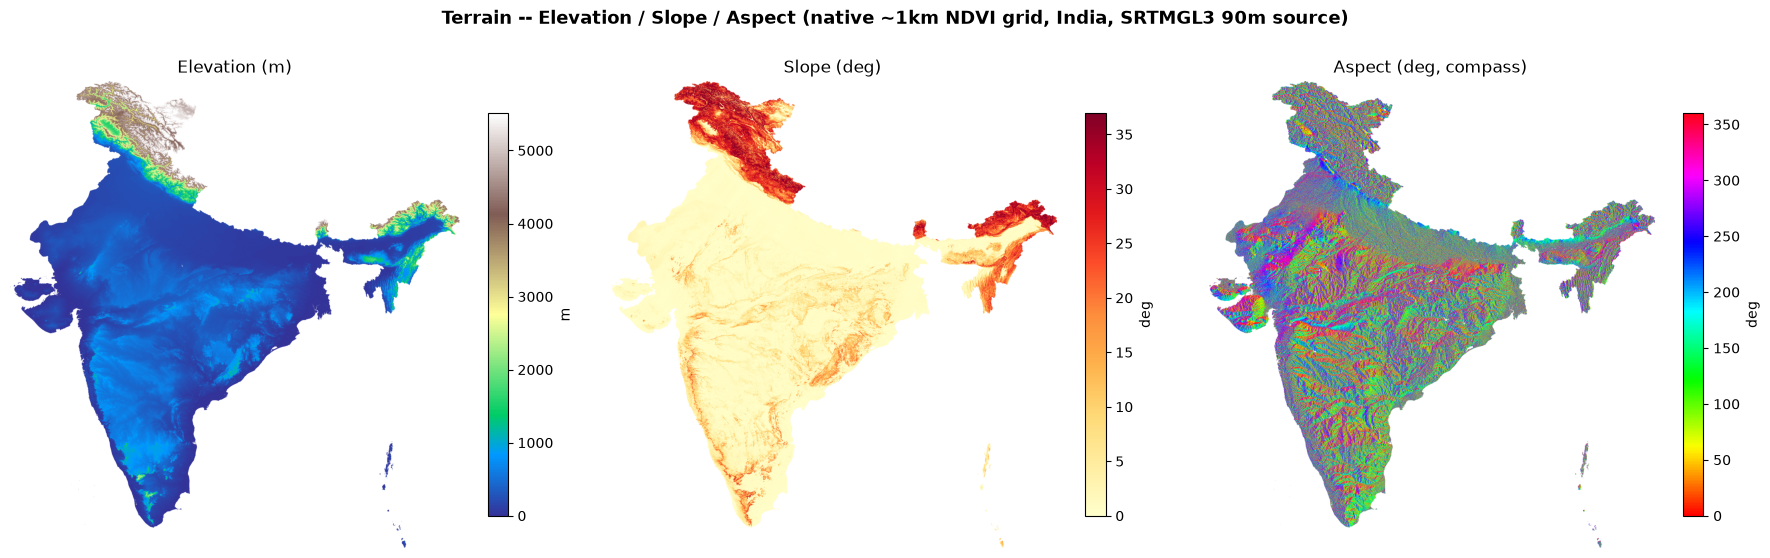

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Terrain -- Elevation / Slope / Aspect (native ~1km NDVI grid, India, SRTMGL3 90m source)",
             fontsize=13, fontweight="bold")

im0 = axes[0].imshow(elevation_1km, cmap="terrain", vmin=0, vmax=np.nanpercentile(elevation_1km, 99))
axes[0].set_title("Elevation (m)"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], label="m", shrink=0.75)

im1 = axes[1].imshow(slope_1km, cmap="YlOrRd", vmin=0, vmax=np.nanpercentile(slope_1km, 99))
axes[1].set_title("Slope (deg)"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], label="deg", shrink=0.75)

im2 = axes[2].imshow(aspect_1km, cmap="hsv", vmin=0, vmax=360)
axes[2].set_title("Aspect (deg, compass)"); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], label="deg", shrink=0.75)

plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, "Terrain_Spatial_Maps.png")
plt.savefig(outfile, dpi=150, bbox_inches="tight")
print(f"Saved: {outfile}")
plt.show()

Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Elevation_Slope_Aspect_Analysis\Terrain_Outputs\Terrain_Fire_Coincidence.png


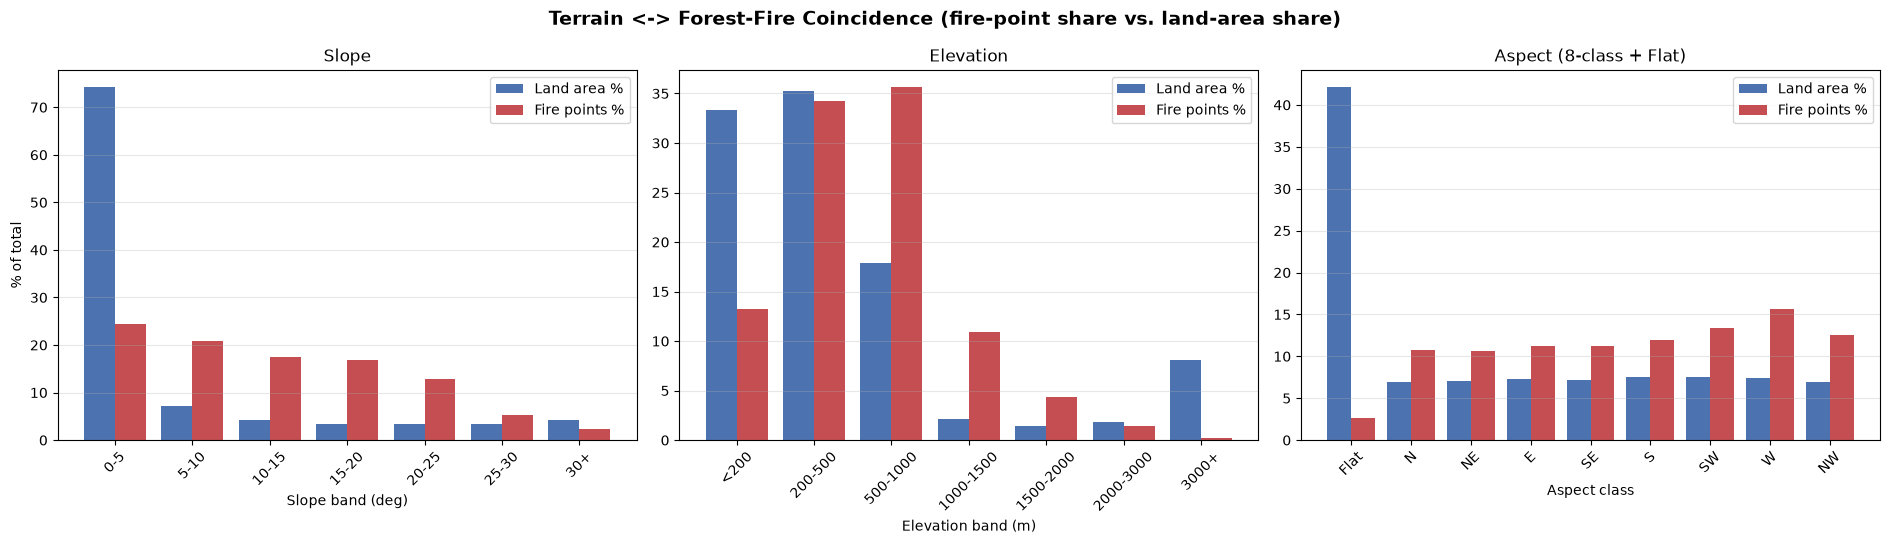

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.suptitle("Terrain <-> Forest-Fire Coincidence (fire-point share vs. land-area share)", fontsize=14, fontweight="bold")

ax = axes[0]
x = np.arange(len(SLOPE_LABELS))
ax.bar(x - 0.2, df_slope_enrich["land_area_pct"], 0.4, label="Land area %", color="#4C72B0")
ax.bar(x + 0.2, df_slope_enrich["fire_pct"], 0.4, label="Fire points %", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(SLOPE_LABELS, rotation=45)
ax.set_xlabel("Slope band (deg)"); ax.set_ylabel("% of total"); ax.set_title("Slope")
ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[1]
x = np.arange(len(ELEV_LABELS))
ax.bar(x - 0.2, df_elev_enrich["land_area_pct"], 0.4, label="Land area %", color="#4C72B0")
ax.bar(x + 0.2, df_elev_enrich["fire_pct"], 0.4, label="Fire points %", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(ELEV_LABELS, rotation=45)
ax.set_xlabel("Elevation band (m)"); ax.set_title("Elevation")
ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[2]
classes_dir = [ASPECT_CLASSES[k] for k in range(9)]
x = np.arange(9)
ax.bar(x - 0.2, df_aspect_enrich["land_area_pct"], 0.4, label="Land area %", color="#4C72B0")
ax.bar(x + 0.2, df_aspect_enrich["fire_pct"], 0.4, label="Fire points %", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(classes_dir, rotation=45)
ax.set_xlabel("Aspect class"); ax.set_title("Aspect (8-class + Flat)")
ax.legend(); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, "Terrain_Fire_Coincidence.png")
plt.savefig(outfile, dpi=150, bbox_inches="tight")
print(f"Saved: {outfile}")
plt.show()

## Step 16 — Output Verification

In [18]:
expected_files = [
    "T1_Elevation_native_1km.tif", "T2_Slope_native_1km.tif", "T3_Aspect_native_1km.tif",
    "T3b_Aspect_8class_native_1km.tif",
    "T1_Elevation_comparison_025deg.tif", "T2_Slope_comparison_025deg.tif",
    "T3_Aspect_comparison_025deg.tif", "T3b_Aspect_8class_comparison_025deg.tif",
    "Terrain_summary_statistics.csv", "Terrain_aspect_summary.csv", "Terrain_Fire_Coincidence.csv",
    "Terrain_Spatial_Maps.png", "Terrain_Fire_Coincidence.png",
]
print("Output verification:")
all_ok = True
for fname in expected_files:
    p = os.path.join(OUTPUT_DIR, fname)
    ok = os.path.exists(p) and os.path.getsize(p) > 0
    all_ok = all_ok and ok
    size = f"{os.path.getsize(p)/1024:.1f} KB" if ok else "MISSING or EMPTY"
    print(f"   [{'OK' if ok else 'FAIL'}] {fname}  ({size})")

print()
print("All outputs present and non-empty" if all_ok else "SOME OUTPUTS ARE MISSING -- investigate above")

Output verification:
   [OK] T1_Elevation_native_1km.tif  (18184.3 KB)


   [OK] T2_Slope_native_1km.tif  (20102.6 KB)
   [OK] T3_Aspect_native_1km.tif  (19657.8 KB)
   [OK] T3b_Aspect_8class_native_1km.tif  (1697.5 KB)
   [OK] T1_Elevation_comparison_025deg.tif  (25.6 KB)
   [OK] T2_Slope_comparison_025deg.tif  (25.4 KB)
   [OK] T3_Aspect_comparison_025deg.tif  (24.6 KB)
   [OK] T3b_Aspect_8class_comparison_025deg.tif  (3.0 KB)
   [OK] Terrain_summary_statistics.csv  (0.8 KB)
   [OK] Terrain_aspect_summary.csv  (0.2 KB)
   [OK] Terrain_Fire_Coincidence.csv  (1.7 KB)
   [OK] Terrain_Spatial_Maps.png  (1102.1 KB)
   [OK] Terrain_Fire_Coincidence.png  (114.1 KB)

All outputs present and non-empty


## Summary

Three new topographic predictor variables built for the India fire-risk pipeline, completing the
remaining 3 of the 6 Biswas et al. (2025) variables this project was missing (the other 3 —
distance to roads/railways/waterways — are the sibling `Accessibility_Distance_Analysis.ipynb`
notebook in this same folder):

| Variable | Native grid | Comparison grid |
|---|---|---|
| Elevation | `T1_Elevation_native_1km.tif` | `T1_Elevation_comparison_025deg.tif` |
| Slope | `T2_Slope_native_1km.tif` | `T2_Slope_comparison_025deg.tif` |
| Aspect (continuous, 0-360 deg) | `T3_Aspect_native_1km.tif` | `T3_Aspect_comparison_025deg.tif` |
| Aspect (8-class + Flat, bonus) | `T3b_Aspect_8class_native_1km.tif` | `T3b_Aspect_8class_comparison_025deg.tif` |

Both resolutions are labeled honestly per this project's resolution-honesty convention: **the native
~1km files are what this pipeline's model actually consumes (Step 6 integration); the 0.25° files
exist only to compare against Biswas et al.'s own working resolution and are not used downstream.**

Slope and aspect were computed with a project-native GPU-vectorized implementation of Horn's (1981)
method at the DEM's native 90m resolution — **before** any resampling, so gradient-based detail isn't
smoothed away by downsampling first — with per-row (latitude-dependent) meters-per-degree spacing
rather than one flat conversion factor for all of India, and verified against two synthetic test
patches with known downslope directions before being run on real data. The DEM's ambiguous
`nodata=0` value (used for both open ocean and any leftover void) was resolved with a documented,
coastline-proximity-based heuristic rather than a blanket rule, to avoid silently discarding genuine
low-lying coastal/deltaic land. Aspect, being circular, was resampled via its sine/cosine components
rather than by naively averaging raw degrees across the 0/360° wraparound.